# Neural Network–Based Object Recognition on the CIFAR-100 Dataset

In [1]:
# importing packages with random states for reproducibility
import torch
torch.manual_seed(42)
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import pickle
import seaborn as sns

# Set random seed for reproducibility
import random
random.seed(42)

# Check PyTorch and CUDA versions
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

Torch version: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
GPU: NVIDIA L40S


Part 1:  Load and visualize some sample data points. Use the built-in dataset class to access the training data (an example is given below).

In [2]:
# Part 1, load and visualise some sample data points 
training_data = datasets.CIFAR100(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.CIFAR100(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

Plot the sample figures 

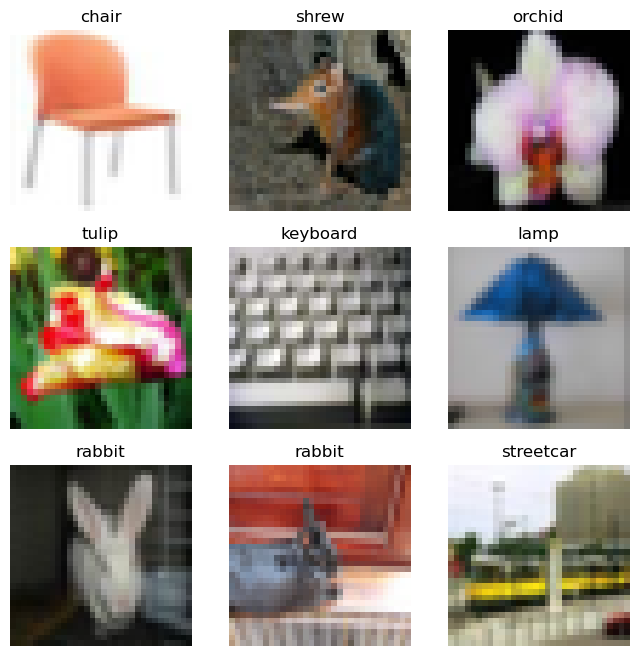

In [3]:
labels_map = test_data.classes  # CIFAR-100 class names

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3

for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(test_data), size=(1,)).item()
    img, label = test_data[sample_idx]

    # convert CHW tensor
    img = img.permute(1, 2, 0)

    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img)

plt.show()

Part 2: Create a custom dataset for CIFAR-100. Create a subclass of
torch.uDls.data.Dataset as a dataset wrapper for CIFAR-100. Implement three funcDons:
__init__, __len__, and __geDtem__. You may review the following example for
reference.

## Functions and Classes
In this part of the notebook I have my various functions and classes needed for the assignment 

Image Dataset class: this is to wrap the data into a PyTorch Dataset, and it allows us to import images even when they are not in the standard pytorch format

In [4]:
# creating the class: image_dataset to import the images in the correct format 
class image_dataset(Dataset):
    # we do this because our training step for the models needs a consistent interface, regardless of where our data comes from 
    def __init__(self, images, labels, transform=None, target_transform=None):
        # Images: array or list of the images
        self.images = images
        # labels: arraw of lables corrisponding to the images
        self.labels = labels
        # optional transform if needed (scaling, normalization,...)
        self.transform = transform
        # optional target transform if needed
        self.target_transform = target_transform

    def __len__(self):
        # return the number of images in our dataset
        return len(self.images)

    def __getitem__(self, idx):
        # get the image and label 
        image = self.images[idx]
        label = self.labels[idx]
        if self.transform is not None:
            image = self.transform(image)
        if self.target_transform is not None:
            label = self.target_transform(label)
        return image, label

Load_cifar100_batch allows us to import the datasets from the directory 

In [5]:
def load_cifar100_batch(path):
    with open(path, "rb") as f:
        data = pickle.load(f, encoding="bytes")
    images = data[b"data"]          # shape (N, 3072)
    labels = np.array(data[b"fine_labels"])
    images = images.reshape(-1, 3, 32, 32)  # CHW
    images = images.transpose(0, 2, 3, 1)   # HWC for transforms
    return images, labels

Once we create our image class we need to import it into DataLoader, where we can specify the batch size for training. 

In [6]:
def make_loaders(train_ds, test_ds, batch_size: int):
    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True)
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=True)
    return train_loader, test_loader

NeuralNetwork is our model, composed of 3 linear layers and 2 ReLU activation functions

In [7]:
# Creating the ANN model, and saving it under the variable model (this is what I will be using in the loop later)
class NeuralNetwork(torch.nn.Module):

    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.flatten = torch.nn.Flatten()
        # flattens into a vector of 32*32*3 = 3072 elements
        self.linear_relu_stack = torch.nn.Sequential(
            torch.nn.Linear(32*32*3, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 256),
            torch.nn.ReLU(),
            torch.nn.Linear(256, 100) # 100 output classes for CIFAR-100
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

Training loop, here we iterate over the small batches of our dataset and optimize the weights at the neurons

In [8]:
# train loop 
def train_loop(data, model, loss_fn, optimizer,device):
    size = len(data.dataset) # total number of samples in the dataset
    model.train()  # set the model to training mode

    for batch, (X, y) in enumerate(data): # thanks to the Dataloader function, batch_size was decided above (64)
        X, y = X.to(device), y.to(device)

        # Compute prediction error (give the image and see which label it predicts)
        pred = model(X) 
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad() # clears old gradients 
        loss.backward() # compute gradients X neuron
        optimizer.step() # changes the weights of the various layers

        # print to keep track of training process
        if batch % 100 == 0:
            loss, current = loss.item(), batch * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

After completing one training loop, we need to test how well our model performs on our test set. To do this I created the test_loop

In [9]:
# test loop 
def test_loop(data, model, loss_fn, device):

    model.eval()  # set the model to evaluation mode

    size = len(data.dataset)
    num_batches = len(data)
    test_loss, correct = 0, 0

    with torch.no_grad(): # no gradients are calculated during tested 
        for X, y in data:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

    return test_loss, correct 

def init_model_and_device(model_cls):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model_cls().to(device)
    return model, device

Now that we have all the individual components to train and test a model, I created one function that contains it all. Here we can also adjust the hyperparameters

In [10]:
def train_with_early_stopping(train_ds,test_ds, model_cls, loss_fn, optimizer_cls, optimizer_kwargs, epochs: int, batch_size: int, test_data_frame, patience: int = 3):
    # Data
    train_loader, test_loader = make_loaders(train_ds, test_ds, batch_size)
    # Model + device
    model, device = init_model_and_device(model_cls)
    print(model)

    optimizer = optimizer_cls(model.parameters(),optimizer_kwargs)
    old_test_loss = float("inf")
    counter = 0
    for t in range(epochs):

        print(f"Epoch {t+1}\n-------------------------------")
        train_loop(train_loader, model, loss_fn, optimizer, device)
        test_loss, correct = test_loop(test_loader, model, loss_fn, device)
        #add to dataframe to plot later
        test_data_frame.loc[len(test_data_frame)] = {"epoch": t + 1,"test_loss": test_loss,"accuracy": correct,"batch_size": batch_size,}

        if test_loss > old_test_loss:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered")
                break
        else:
            counter = 0
        old_test_loss = test_loss
    print("Done!")
    return model, test_data_frame

Now we are running my experiment on whether batch size influences the output (i.e overall accuracy, loss and number of epochs needed). Additionally I have added the transformation (ToTensor and ToPILImage) to the train and test set. Furthermore on the train set I use RandomHorizontalFlip, in order for it to generalize better on the testing set.

In [11]:
# importing the data, already split in train and test from https://www.cs.toronto.edu/~kriz/cifar.html
train_images, train_labels = load_cifar100_batch("/users/jmatthia/deep_learning/data/cifar-100-python/train")
# train_images shape (50000, 32, 32, 3), train_labels shape (50000,) --> but not in tensor or any particular format yet
test_images, test_labels = load_cifar100_batch("/users/jmatthia/deep_learning/data/cifar-100-python/test")

train_tfms = transforms.Compose([
    transforms.ToPILImage(), # format conversion to PIL image 
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

test_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor()
])

train_ds= image_dataset(images=train_images, labels=train_labels, transform=train_tfms, target_transform=None)
test_ds= image_dataset(images=test_images, labels=test_labels, transform=test_tfms, target_transform=None)

# creating a dataframe for storing the results of the test loop
test_data_frame= pd.DataFrame(columns=["epoch", "test_loss", "accuracy", "batch_size"])

Now I want to run the model across the three different batch sizes

In [12]:
epochs=[64,128,256]

for epoch_size in epochs:
     model, test_data_frame = train_with_early_stopping(
        train_ds=train_ds,
        test_ds=test_ds,
        model_cls=NeuralNetwork,
        loss_fn=torch.nn.CrossEntropyLoss(),
        optimizer_cls=torch.optim.SGD,      
        optimizer_kwargs=0.01,
        epochs=150,
        batch_size=epoch_size,
        test_data_frame=test_data_frame,
        patience=3)


NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=3072, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=100, bias=True)
  )
)
Epoch 1
-------------------------------
loss: 4.603665  [    0/50000]
loss: 4.600635  [ 6400/50000]
loss: 4.584626  [12800/50000]
loss: 4.583091  [19200/50000]
loss: 4.552155  [25600/50000]
loss: 4.549893  [32000/50000]
loss: 4.529649  [38400/50000]
loss: 4.536591  [44800/50000]
Test Error: 
 Accuracy: 2.4%, Avg loss: 4.520490 

Epoch 2
-------------------------------
loss: 4.513849  [    0/50000]
loss: 4.514442  [ 6400/50000]
loss: 4.480423  [12800/50000]
loss: 4.399379  [19200/50000]
loss: 4.384902  [25600/50000]
loss: 4.284091  [32000/50000]
loss: 4.232877  [38400/50000]
loss: 4.269586  [44800/50000]
Test Error: 
 Accuracy: 5.7%, Avg loss: 4.217248 

Epoch 3
---------

After Running the model I want to plot the Loss curve and accuracy vs epochs 

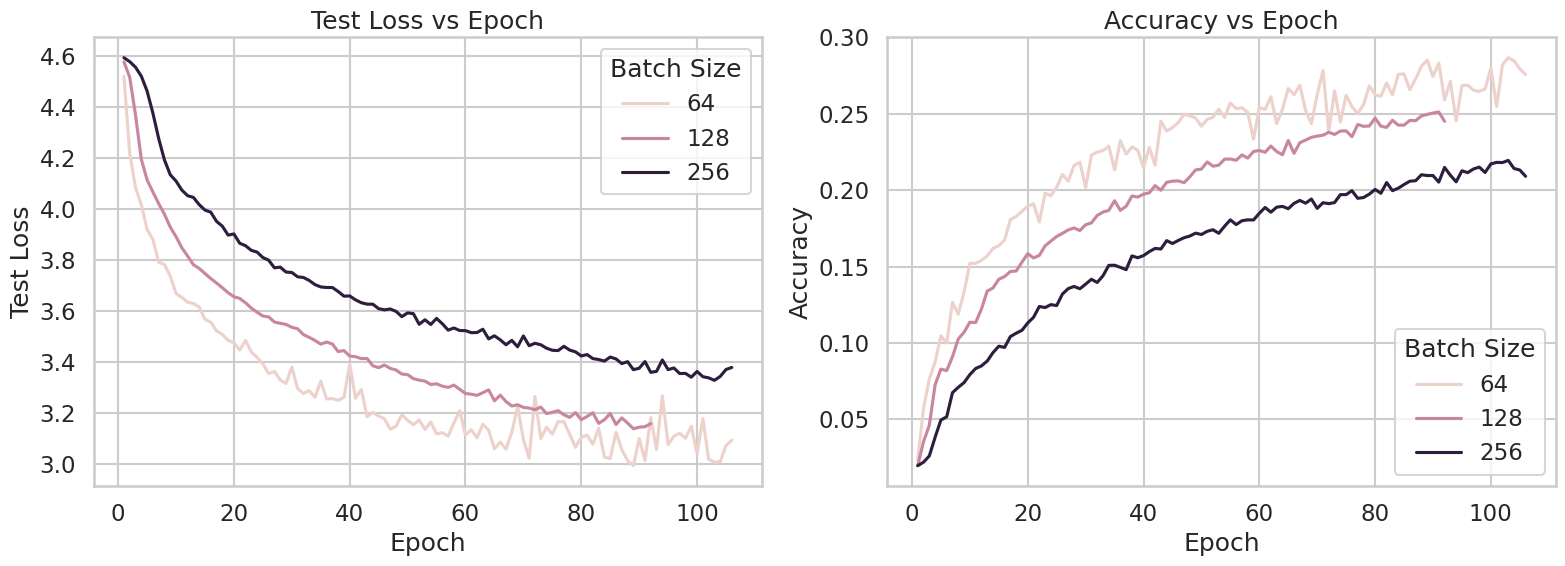

In [13]:
sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
# --- Test loss ---
sns.lineplot(data=test_data_frame,x="epoch", y="test_loss", hue="batch_size",ax=axes[0])
axes[0].set_title("Test Loss vs Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Test Loss")
axes[0].legend(title="Batch Size")
# --- Accuracy ---
sns.lineplot( data=test_data_frame, x="epoch", y="accuracy", hue="batch_size",ax=axes[1])
axes[1].set_title("Accuracy vs Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend(title="Batch Size")

plt.tight_layout()
plt.savefig("cifar100_ann_results.png")
plt.show()
